# Model predictive control

Closed-loop control of a double integrator, re-solving a QP at every step. The constraints are checked over the whole trajectory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cuprox

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
GPU = "#76B900"
REF = "#546778"

assert cuprox.__cuda_available__, (
    "This notebook must run against a CUDA build. Install with `pip install .` "
    "from the repository root; installing python/ alone does not build the "
    "extension."
)
from cuprox import _core
print(f"cuProx {cuprox.__version__} on {_core.get_device_name()}")

from cuprox.mpc import LinearMPC, double_integrator

cuProx 0.2.0 on NVIDIA RTX A6000


## Plant and controller

States are position and velocity; the input is acceleration, limited to `|u| ≤ 1`. The controller drives the state to the origin from `x₀ = [5, 0]`.

In [2]:
dt = 0.1
system = double_integrator(dt=dt)

mpc = LinearMPC(
    system,
    horizon=25,
    Q=np.diag([10.0, 1.0]),
    R=np.array([[0.1]]),
    u_min=np.array([-1.0]),
    u_max=np.array([1.0]),
)
print(f"states {mpc.n_x}, inputs {mpc.n_u}, horizon {mpc.horizon}")

states 2, inputs 1, horizon 25


## Closed loop

In [3]:
import time

x = np.array([5.0, 0.0])
xs, us, solve_ms = [x.copy()], [], []

for _ in range(80):
    t0 = time.perf_counter()
    res = mpc.solve(x, max_iters=20_000, tolerance=1e-6)
    solve_ms.append((time.perf_counter() - t0) * 1e3)
    u = np.atleast_1d(res.u)[0] if np.ndim(res.u) > 1 else np.atleast_1d(res.u)[:mpc.n_u]
    x = system.A @ x + system.B @ u
    xs.append(x.copy())
    us.append(u.copy())

xs = np.array(xs)
us = np.array(us)
print(f"median solve {np.median(solve_ms):.2f} ms over {len(solve_ms)} steps")
print(f"final state  [{xs[-1, 0]:+.4f}, {xs[-1, 1]:+.4f}]")

# The input limit must hold at every step, and the state must converge.
assert np.all(us <= 1.0 + 1e-4) and np.all(us >= -1.0 - 1e-4)
assert np.abs(xs[-1]).max() < 0.05
assert np.abs(xs[-1]).max() < np.abs(xs[0]).max()

median solve 785.86 ms over 80 steps
final state  [+0.0000, -0.0002]


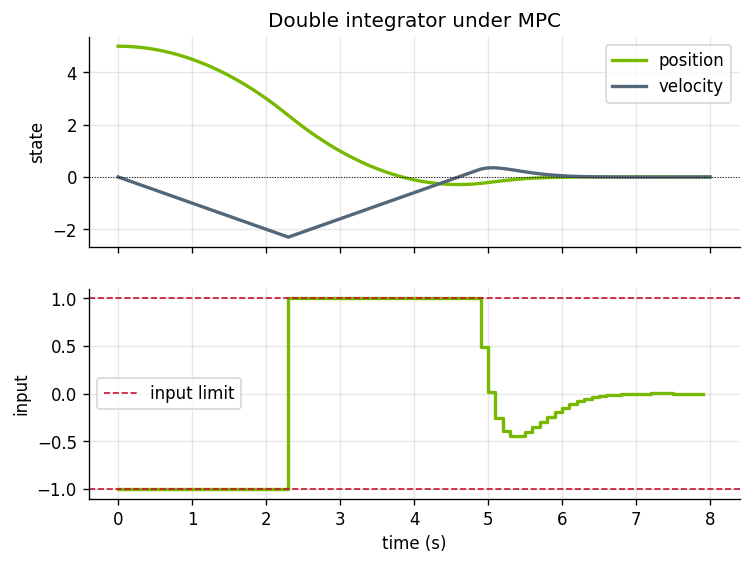

In [4]:
t = np.arange(len(xs)) * dt
fig, (a, b) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
a.plot(t, xs[:, 0], color=GPU, lw=2, label="position")
a.plot(t, xs[:, 1], color=REF, lw=2, label="velocity")
a.axhline(0, color="k", lw=0.6, ls=":")
a.set_ylabel("state")
a.set_title("Double integrator under MPC")
a.legend()

b.step(t[:-1], us[:, 0], where="post", color=GPU, lw=2)
b.axhline(1.0, color="#C8102E", ls="--", lw=1)
b.axhline(-1.0, color="#C8102E", ls="--", lw=1, label="input limit")
b.set_xlabel("time (s)")
b.set_ylabel("input")
b.legend()
fig.savefig("mpc_double_integrator.png")
plt.show()

The input saturates at the limit while the position is far from the target and comes off the bound as the state approaches the origin, which is the behaviour the constraint is there to produce.